### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Input data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 10       # number of modelling nodes

In [6]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [7]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
E = 207e9
G = 79.3e9

In [10]:
# integration parameters
tspan = (0., 4)

### Main functions:

In [11]:
Ar=np.pi*(d0/2)**2

In [12]:
def Πe(φ,θ,ψ):
    return np.array([[np.cos(θ),0,np.cos(φ)*np.sin(θ)],
                  [0,1,-np.sin(φ)],
                  [-np.sin(θ),0,np.cos(φ)*np.cos(θ)]])

In [13]:
def Ret_e_t(φ,θ,ψ):
        Cφ=np.array([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return Cθ @ Cφ @ Cψ

In [14]:
diag_J_t_rho = 1e2*np.array([1, 1, 2]) # [m^4] 
J_t_rho = np.diag(diag_J_t_rho)

In [15]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [16]:
diag_CR = 1e11*np.array([1, 1, 1]) 
CR=np.diag(diag_CR)

In [17]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [18]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [19]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [20]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [21]:
def ωe(φ,θ,ψ): 
    return Πe(φ,θ,ψ)@theta(φ,θ,ψ)

In [22]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [23]:
def d_s_phi(x,y,z,φ,θ,ψ):
    a1, a2, a3 = ωe(φ,θ,ψ)
    return S(a1, a2, a3 )@phi(x,y,z)

In [24]:
def ne(x, y, z, φ, θ, ψ):
    return (Ret_e_t(φ,θ,ψ)@CT@Ret_e_t(φ,θ,ψ).T@(d_s_phi(x,y,z,φ,θ,ψ).reshape(3,1)
            -Ret_e_t(φ,θ,ψ)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)

In [25]:
def me( φ, θ, ψ):
    return Ret_e_t(φ,θ,ψ)@CR@Ret_e_t(φ,θ,ψ).T@ωe(φ,θ,ψ)

In [26]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):

    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ)*np.sin(θ)],
        [0,              0,  -np.cos(φ)            ],
        [0,              0,  -np.sin(φ)*np.cos(θ)]
    ])
    
    dPi_dtheta = np.array([
        [-np.sin(θ),   0,   np.cos(φ)*np.cos(θ)],
        [0,              0,   0                     ],
        [-np.cos(θ),   0,  -np.cos(φ)*np.sin(θ)]
    ])
    
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ + dPi_dtheta * dθ + dPi_dpsi * dψ

In [27]:
fe_g = np.array([0,0,-mp*9.81])          

In [28]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [29]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

### Static solution

In [30]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [31]:
mi = [mp for i in range(N)]

In [32]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [33]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [34]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [35]:
delta_x=horizontal_length/(N-1)

In [36]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [37]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

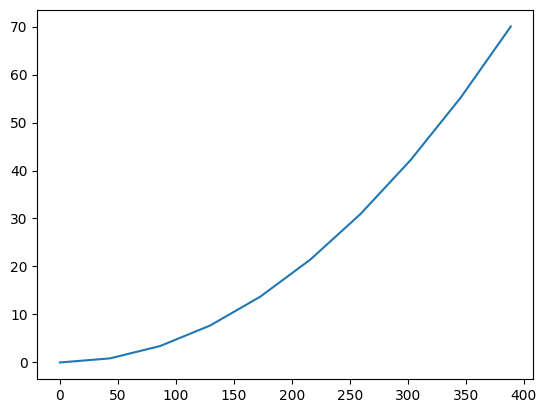

In [38]:
plt.plot(x0, z0)
plt.show()

In [39]:
q0=np.zeros(12*N)

In [40]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [41]:
h = length_p1[-1]/N

In [42]:
def fun1(x_int,φ,θ,ψ):
    A=mp*1/2*(1+x_int)*1/2*(1-x_int)*np.identity(3)
    B=np.zeros((3,3))
    D=1/2*(1+x_int)*1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
    return h/2*np.block([[A, B], [B, D]])

def fun2(x_int,x,y,z,φ,θ,ψ):
    A=1/h*np.identity(3)
    B=np.zeros((3,3))
    C=-1/2*(1+x_int)*S(*d_s_phi(x,y,z,φ,θ,ψ))
    return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x, y, z, φ, θ, ψ)),
                                                          np.asarray(me( φ, θ, ψ))), axis=None)


def fun3(x_int,φ,θ,ψ, dφ, dθ, dψ):
    A=np.zeros(3)
    B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun4(x_int,φ,θ,ψ, dφ, dθ, dψ):
    A=np.zeros(3)   
    B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun5(x_int):
    B=np.zeros(3)   
    A=1/2*(1+x_int)*fe_g
    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun6(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
    B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

    return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

def fun7(x_int,x,y,z):
    A=1/2*(1+x_int)*sigma(x,y,z)
    B=np.zeros(3) 

    ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

    return ans

In [43]:
def Assemble(K,k,i,j):
    K[3*i,3*i] = K[3*i,3*i] + k[0,0]
    K[3*i,3*i+1] = K[3*i,3*i+1] + k[0,1]    
    K[3*i,3*i+2] = K[3*i,3*i+2] + k[0,2]
    K[3*i,3*j] = K[3*i,3*j] + k[0,3]
    K[3*i,3*j+1] = K[3*i,3*j+1] + k[0,4]
    K[3*i,3*j+2] = K[3*i,3*j+2] + k[0,5]
    K[3*i+1,3*i] = K[3*i+1,3*i] + k[1,0]
    K[3*i+1,3*i+1] = K[3*i+1,3*i+1] + k[1,1]
    K[3*i+1,3*i+2] = K[3*i+1,3*i+2] + k[1,2]
    K[3*i+1,3*j] = K[3*i+1,3*j] + k[1,3]
    K[3*i+1,3*j+1] = K[3*i+1,3*j+1] + k[1,4]
    K[3*i+1,3*j+2] = K[3*i+1,3*j+2] + k[1,5]
    K[3*i+2,3*i] = K[3*i+2,3*i] + k[2,0]
    K[3*i+2,3*i+1] = K[3*i+2,3*i+1] + k[2,1]
    K[3*i+2,3*i+2] = K[3*i+2,3*i+2] + k[2,2]
    K[3*i+2,3*j] = K[3*i+2,3*j] + k[2,3]
    K[3*i+2,3*j+1] = K[3*i+2,3*j+1] + k[2,4]
    K[3*i+2,3*j+2] = K[3*i+2,3*j+2] + k[2,5]
    K[3*j,3*i] = K[3*j,3*i] + k[3,0]
    K[3*j,3*i+1] = K[3*j,3*i+1] + k[3,1]
    K[3*j,3*i+2] = K[3*j,3*i+2] + k[3,2]
    K[3*j,3*j] = K[3*j,3*j] + k[3,3]
    K[3*j,3*j+1] = K[3*j,3*j+1] + k[3,4]
    K[3*j,3*j+2] = K[3*j,3*j+2] + k[3,5]   
    K[3*j+1,3*i] = K[3*j+1,3*i] + k[4,0]
    K[3*j+1,3*i+1] = K[3*j+1,3*i+1] + k[4,1]
    K[3*j+1,3*i+2] = K[3*j+1,3*i+2] + k[4,2]
    K[3*j+1,3*j] = K[3*j+1,3*j] + k[4,3]
    K[3*j+1,3*j+1] = K[3*j+1,3*j+1] + k[4,4]
    K[3*j+1,3*j+2] = K[3*j+1,3*j+2] + k[4,5]
    K[3*j+2,3*i] = K[3*j+2,3*i] + k[5,0]
    K[3*j+2,3*i+1] = K[3*j+2,3*i+1] + k[5,1]
    K[3*j+2,3*i+2] = K[3*j+2,3*i+2] + k[5,2]
    K[3*j+2,3*j] = K[3*j+2,3*j] + k[5,3]
    K[3*j+2,3*j+1] = K[3*j+2,3*j+1] + k[5,4]
    K[3*j+2,3*j+2] = K[3*j+2,3*j+2] + k[5,5]
    
    return K

In [44]:
def static_solution(Q): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    f2=np.zeros(3*N) 
    f3=np.zeros(3*N) 
    f4=np.zeros(3*N) 
    f5=np.zeros(3*N) 
    f6=np.zeros(3*N) 
#     f7=np.zeros(3*N)
    
    
    K_stat=np.zeros(shape=(3*N,3*N))
    for j in range(1,N-1):
        K_stat=Assemble(K_stat,fun1(-1/np.sqrt(3),φ[j],θ[j],ψ[j])+fun1(1/np.sqrt(3),φ[j],θ[j],ψ[j]),j-1,j)
        start = 3 * j
        end = start + 6
        f2[start:end] += 2*fun2(0,x[j],y[j],z[j],φ[j],θ[j],ψ[j])
        f3[start:end] += (fun3(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                            +fun3(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f4[start:end] +=  (fun4(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                            +fun4(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f5[start:end] += fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3))
        f6[start:end] += (fun6(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
                            +fun6(1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
#         f7[start:end] += fun7(-1/np.sqrt(3),x[j],y[j],z[j])+fun7(1/np.sqrt(3),x[j],y[j],z[j])

    F=f2+f3+f4+f5+f6  
    

    bc=np.array([[0,1,2], 
                 [0,0,0]]).T
    
    nd, nd=K_stat.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    
    K_stat[np.isnan(K_stat)] = 0
    F[np.isnan(F)] = 0
    
    
    s=np.linalg.solve(K_stat[fdof,:][:,fdof] + 1e-5 * np.eye(3*(N-1)),
                      (F[fdof].T-np.dot(K_stat[fdof,:][:,pdof],dp.T)).T) 
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    
     
    ddx=ddy=ddz=ddφ=ddθ=ddψ=np.zeros(N) 
    
    for i in range(1,N-1):
        start = 3 * i
        ddx[i]=d[start]
        ddy[i]=d[start+1]
        ddz[i]=d[start+2]
        ddφ[i]=d[start+3]
        ddθ[i]=d[start+4]
        ddψ[i]=d[start+5]
  

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    return ans

In [45]:
root_ = root(static_solution, q0, method='krylov')

In [46]:
root_

 message: A solution was found at the specified tolerance.
 success: True
  status: 1
     fun: [ 0.000e+00  2.751e-12 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  4.323e+01 ...  0.000e+00  0.000e+00]
     nit: 6
  method: krylov

In [47]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [48]:
q0 = root_.x                                         # start from static solution

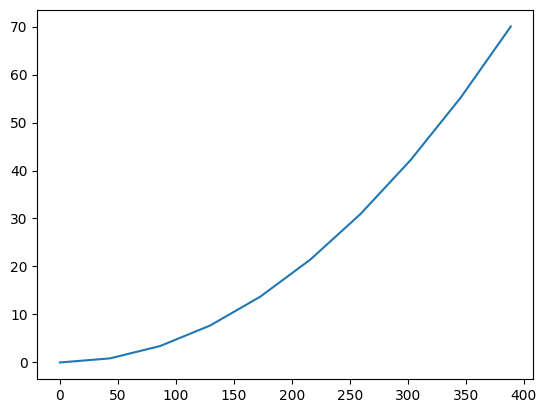

In [49]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [50]:
sampleTime = 0.001              # sample time [seconds]
Number = 60000                      # number of samples

In [51]:
Number*sampleTime

60.0

In [52]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [53]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [54]:
simData.shape 

(60001, 24)

In [55]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

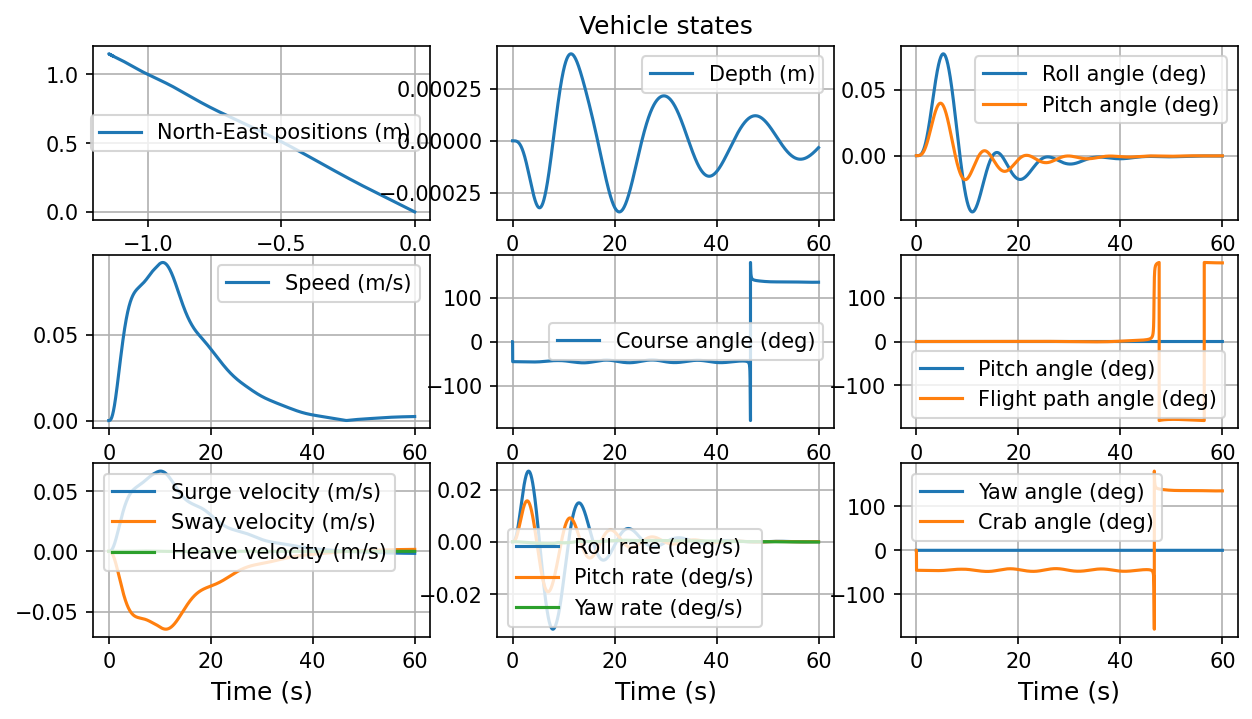

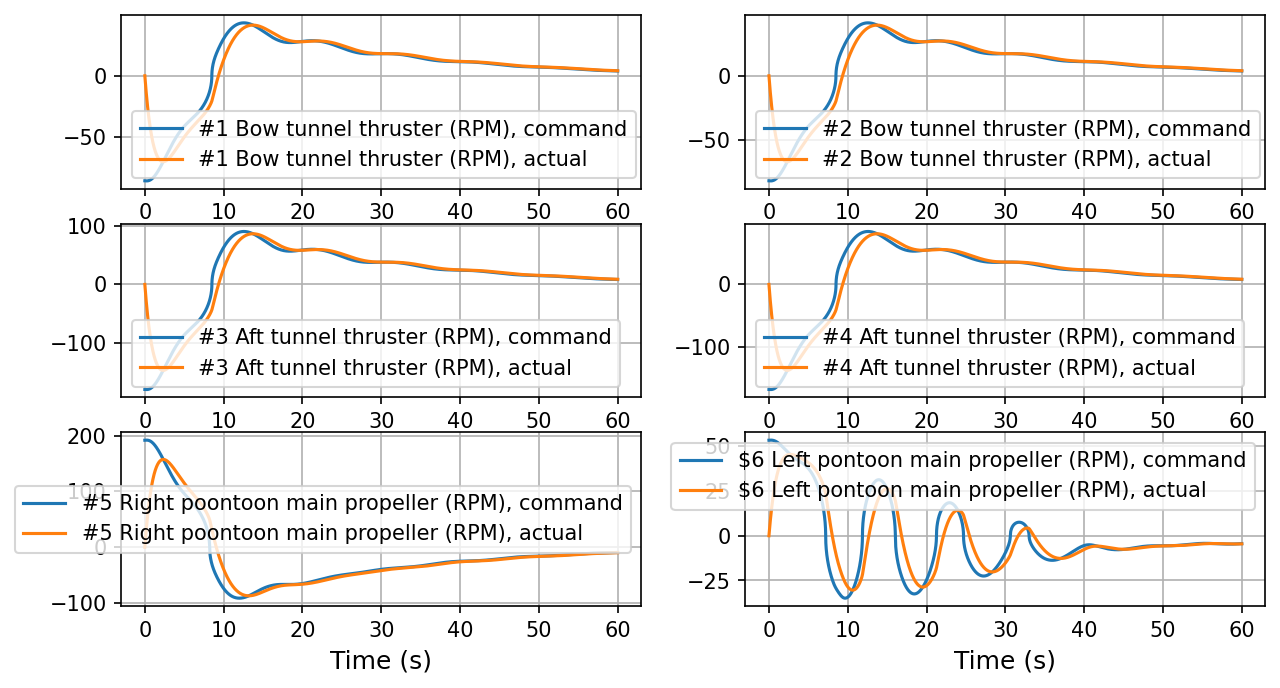

In [56]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [57]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

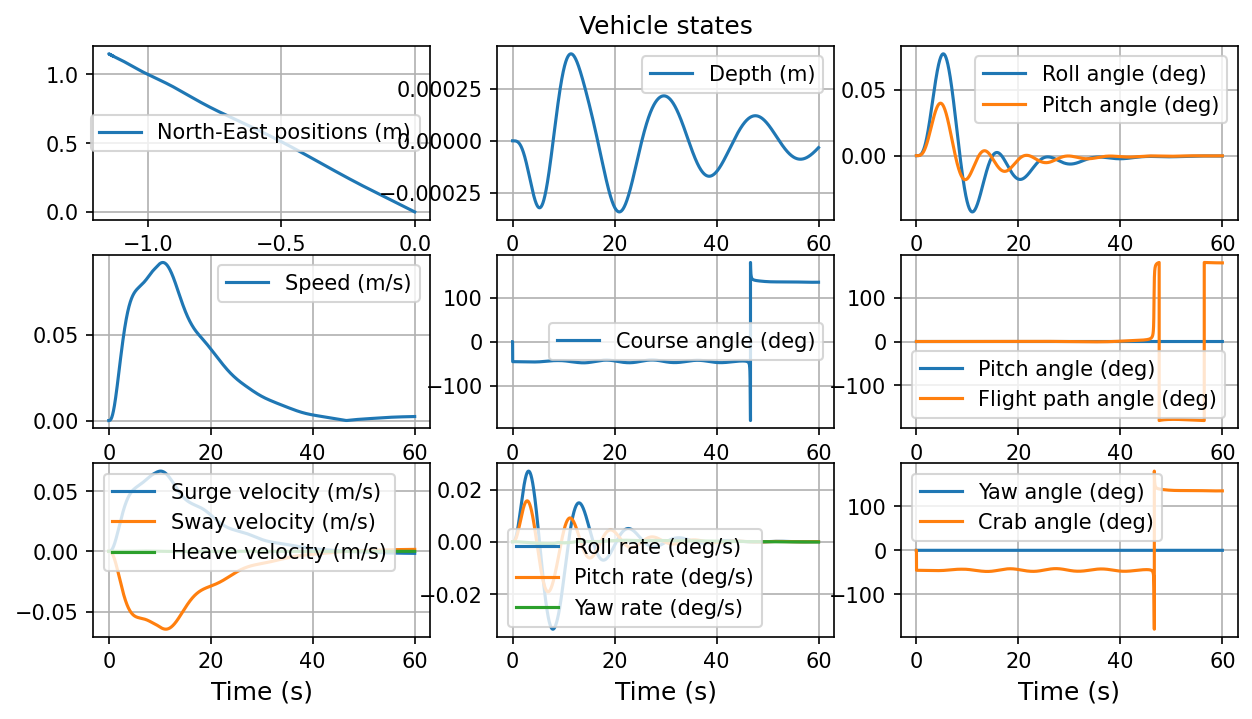

In [58]:
plotVehicleStates(simTime, simData, 3)

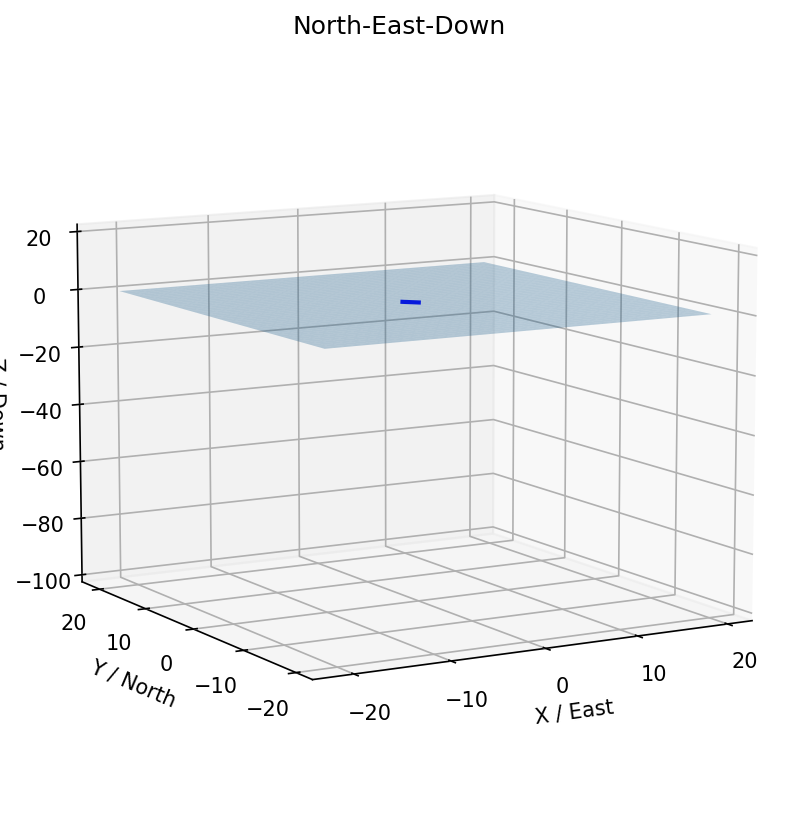

In [59]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [60]:
simData.shape

(60001, 24)

In [61]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [62]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamic Simulation

In [103]:
def dynamic_func(t, Q, T):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
        
    u_actual_x = simData[:, 18][idx]
    u_actual_y = simData[:, 19][idx]
    u_actual_z = simData[:, 20][idx]
    u_actual_phi = simData[:, 21][idx]
    u_actual_theta = simData[:, 22][idx]
    u_actual_psi = simData[:, 23][idx]
    
    u_actual=np.array([u_actual_x, u_actual_y, u_actual_z, u_actual_phi, u_actual_theta, u_actual_psi])
        
        
    f2=np.zeros(3*N) 
    f3=np.zeros(3*N) 
    f4=np.zeros(3*N) 
    f5=np.zeros(3*N) 
    f6=np.zeros(3*N) 
    f7=np.zeros(3*N) 
    f8=np.zeros(3*N)
    
    K_stat=np.zeros(shape=(3*N,3*N))
    for j in range(1, N-2):
        K_stat=Assemble(K_stat,fun1(-1/np.sqrt(3),φ[j],θ[j],ψ[j])+fun1(1/np.sqrt(3),φ[j],θ[j],ψ[j]),j,j+1)
        start = 3 * j
        end = start + 6
        f2[start:end] +=2*fun2(0,x[j],y[j],z[j],φ[j],θ[j],ψ[j])
        f3[start:end] += (fun3(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                            +fun3(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f4[start:end] +=  (fun4(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
                      +fun4(1/np.sqrt(3),φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
        f5[start:end] += fun5(-1/np.sqrt(3))+fun5(1/np.sqrt(3))
        f6[start:end] += (fun6(-1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
                      +fun6(1/np.sqrt(3),φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
#         f7[start:end] += fun7(-1/np.sqrt(3),x[j],y[j],z[j])+fun7(1/np.sqrt(3),x[j],y[j],z[j])
    
    
       
        if t>0.001:
            ax=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j]))@ ne(x[j], y[j], z[j], φ[j], θ[j], ψ[j]).T

            T.top_tension=max(T.top_tension, ax[0][0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j])) @ me( φ[j], θ[j], ψ[j]).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)
            
    f8[-6:] += (np.block([[np.identity(3), np.zeros((3,3))], [np.zeros((3,3)), np.identity(3)]])@u_actual)    
    
    F=f2+f3+f4+f5+f6+f8  
    
    bc=np.array([[0,1,2], 
                 [0,0,0]]).T
    nd, nd=K_stat.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    
    K_stat[np.isnan(K_stat)] = 0
    F[np.isnan(F)] = 0
    
    s=np.linalg.solve(K_stat[fdof,:][:,fdof] + 1e-5 * np.eye(3*(N-1)), 
                      (F[fdof].T-np.dot(K_stat[fdof,:][:,pdof],dp.T)).T)
    
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
     
    ddx=ddy=ddz=ddφ=ddθ=ddψ=np.zeros(N) 
    
    for i in range(1,N-1):
        start = 3 * i
        ddx[i]=d[start]
        ddy[i]=d[start+1]
        ddz[i]=d[start+2]
        ddφ[i]=d[start+3]
        ddθ[i]=d[start+4]
        ddψ[i]=d[start+5] 
        
        
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
   
    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()  
        
        
    T.my_iter+=1 
    
    
    return ans

In [104]:
T_ = MyTime()

In [105]:
# initial conditions - to control dynamics
BC=np.zeros(N)
BC[-1]=0.013
q0[8*N:9*N] = BC

In [106]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_, ), 
             method='RK23'
               )
print(datetime.now() - startTime1)

(30,)
(30,)
Physical time:  6.600637584180646e-06  Iteration wall-clock time:  0:00:00.608430
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)
(30,)


Traceback (most recent call last):
  File "/Users/giga/Library/Python/3.9/lib/python/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/6q/zp3bjthx3zv4n0bl2l835qdw0000gn/T/ipykernel_18401/3867293526.py", line 2, in <module>
    us_ = solve_ivp(dynamic_func,
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/integrate/_ivp/ivp.py", line 650, in solve_ivp
    message = solver.step()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/integrate/_ivp/base.py", line 197, in step
    success, message = self._step_impl()
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/integrate/_ivp/rk.py", line 144, in _step_impl
    y_new, f_new = rk_step(self.fun, t, y, self.f, h, self.A,
  File "/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/integrate/

### Results

In [67]:
T_.my_iter

619049

In [68]:
# max axial tension
T_.top_tension

53577.98065690597

In [69]:
# max bending strain
T_.sagbend_strain

0.00010312988735772978

In [70]:
fin=us_

In [71]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.488e-05 ...  4.000e+00  4.000e+00]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 4.323e+01  4.323e+01 ...  4.323e+01  4.323e+01]
            ...
            [ 0.000e+00  0.000e+00 ...  1.494e+07  1.494e+07]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 619049
     njev: 0
      nlu: 0

In [72]:
t=fin.t

In [73]:
fin=fin.y.T

In [74]:
t.shape, fin.shape

((147656,), (147656, 120))

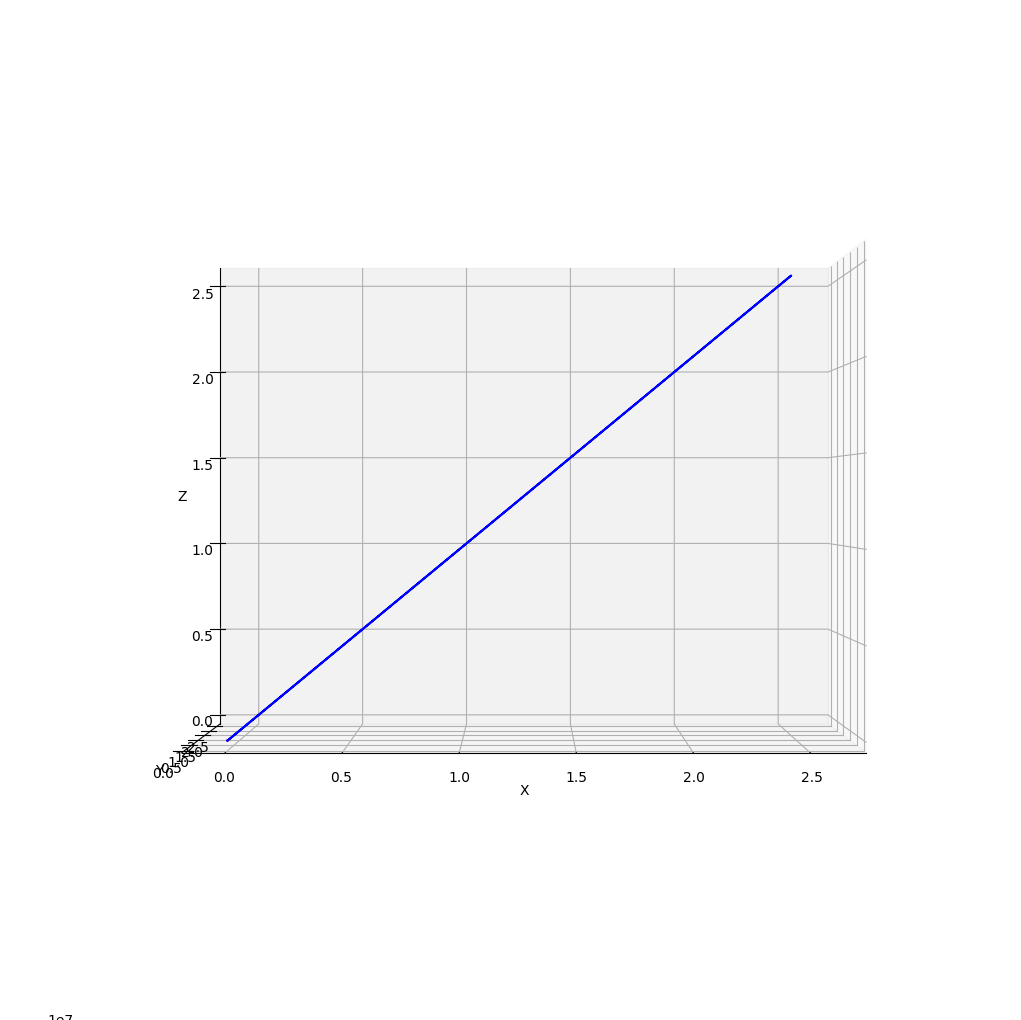

In [75]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [76]:
X,Y,Z

(array([0.00000000e+00, 4.32252340e+01, 8.64504679e+01, 1.29675702e+02,
        1.72900936e+02, 2.16126170e+02, 2.59351404e+02, 3.02576638e+02,
        2.55363953e+07, 3.89027106e+02]),
 array([ 0.00000000e+00, -4.75356285e-09, -2.27550476e-09, -1.51758538e-09,
        -1.15131556e-09, -9.31673122e-10, -8.38613830e-10, -3.09775530e-12,
         2.55360495e+07,  0.00000000e+00]),
 array([0.00000000e+00, 8.55338588e-01, 3.42269387e+00, 7.70608644e+00,
        1.37122243e+01, 2.14505133e+01, 3.09330720e+01, 4.21747505e+01,
        2.55361047e+07, 7.00086695e+01]))

In [77]:
X0,Y0,Z0

(array([  0.        ,  43.22523396,  86.45046792, 129.67570189,
        172.90093585, 216.12616981, 259.35140377, 302.57663774,
        345.8018717 , 389.02710566]),
 array([ 0.00000000e+00, -4.51579973e-09, -2.16160211e-09, -1.44085408e-09,
        -1.09201177e-09, -8.86960226e-10, -7.49247554e-10, -6.96939261e-10,
         0.00000000e+00,  0.00000000e+00]),
 array([ 0.        ,  0.85533859,  3.42269387,  7.70608644, 13.71222428,
        21.45051329, 30.93307201, 42.17475054, 55.1931539 , 70.00866951]))

In [78]:
us=fin.T

In [79]:
us.shape

(120, 147656)

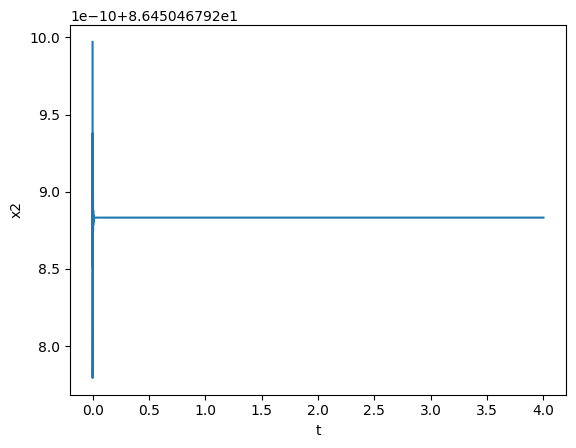

In [80]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

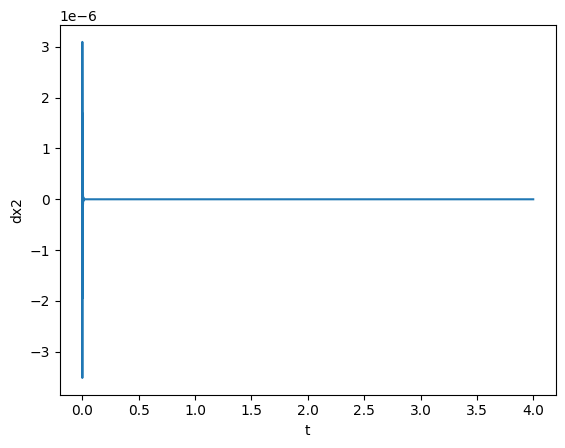

In [81]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

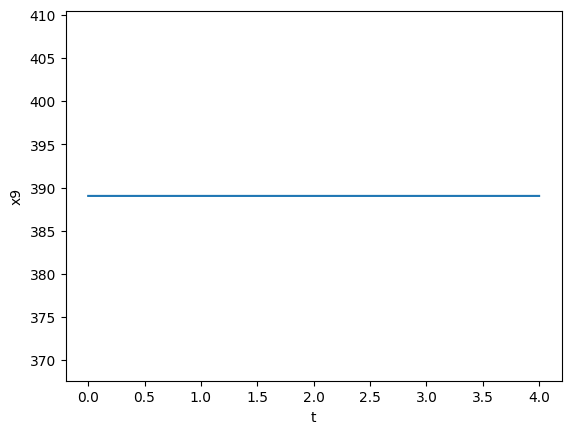

In [82]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

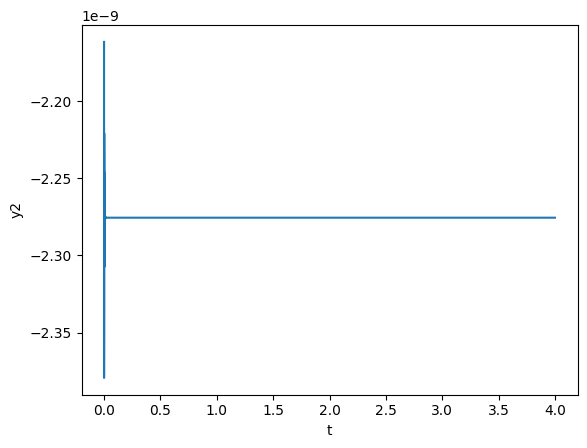

In [83]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

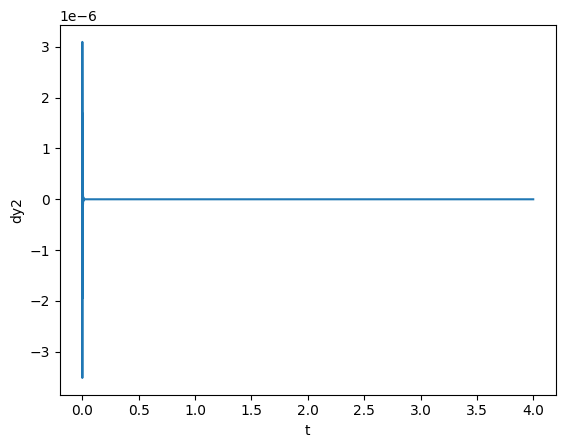

In [84]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

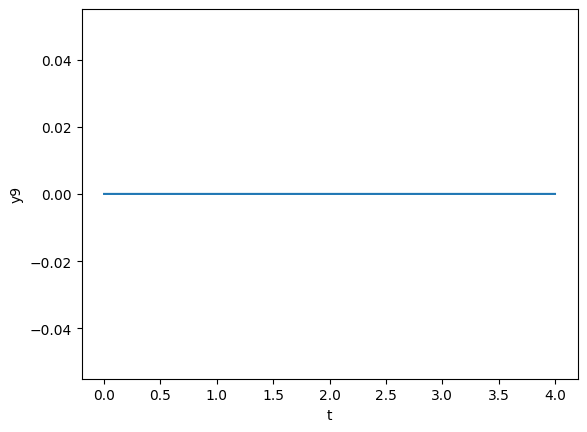

In [85]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

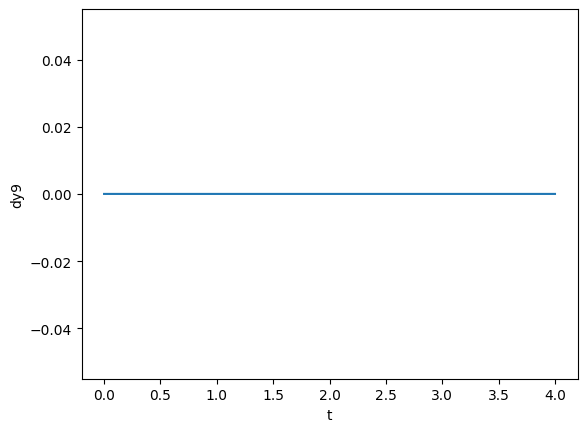

In [86]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

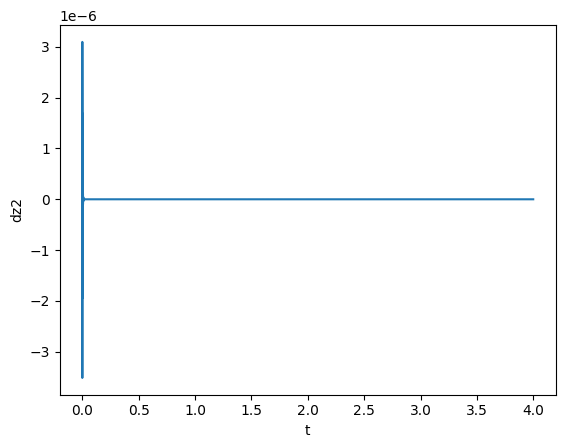

In [87]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

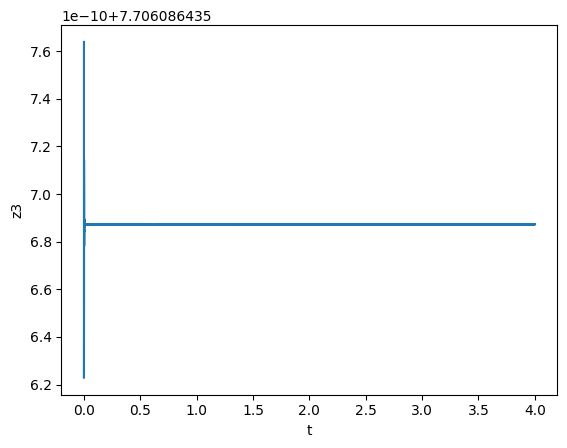

In [88]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

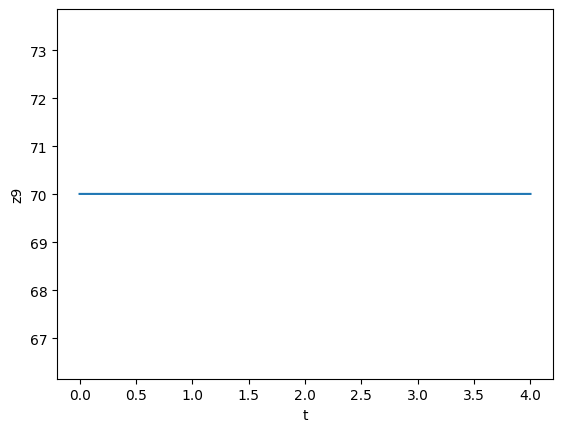

In [89]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

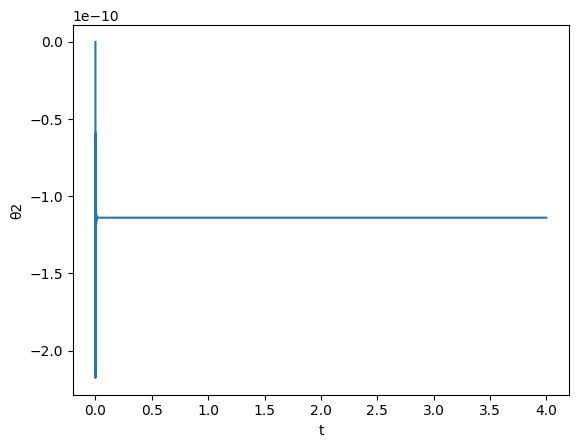

In [90]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

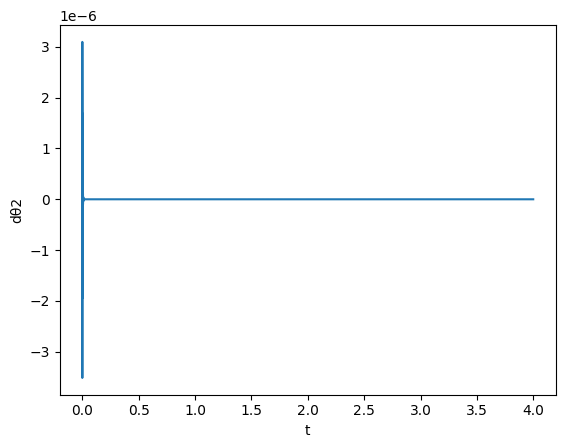

In [91]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

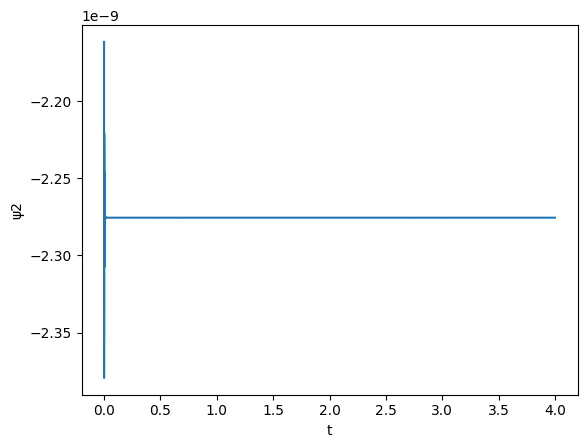

In [92]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

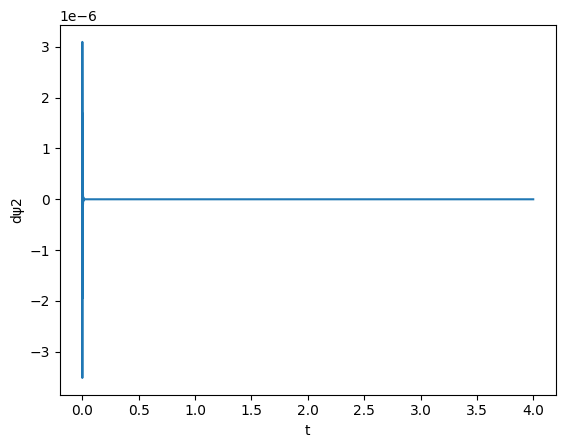

In [93]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

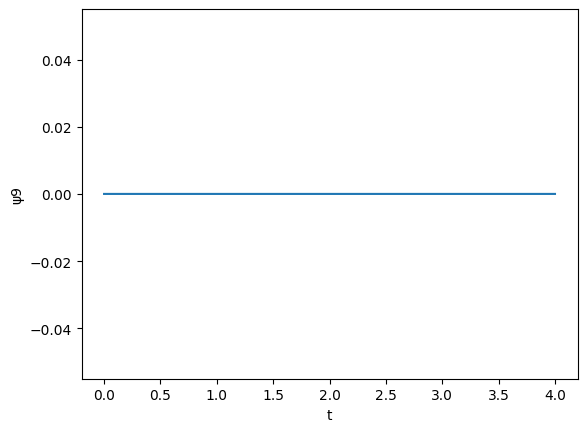

In [94]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [95]:
X010=us.T[:,0*N:1*N]

In [96]:
Y010=us.T[:,2*N:3*N]

In [97]:
Z010=us.T[:,4*N:5*N]

In [98]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()